## Building and Analyzing Binary Classification Systems

### Machine Learning Alrorithms
### By Jay Vardhan Ghildiyal a1953779

## Data Exploration and Analysis

in this section, we explore the nature of the dataset provided and determine preprocessing steps

### Data Inspection

we start by loading our dataset

In [2]:
import numpy as np

# loading the dataset
data = np.load("mnist_1_7_subsets.npz")

# checking the data type of the data variable
print(type(data))
# so this is a dictionary , as opposed to a pandas dataframe

# checking the keys of the data variable
print(list(data.keys()))

<class 'numpy.lib.npyio.NpzFile'>
['train_data', 'train_targets', 'test_data', 'test_targets']


now that we know the contents and the name of the keys, we can seperate them according to their roles

In [3]:
# create different arrays for each key
X_train = data["train_data"]
y_train = data["train_targets"]
X_test = data["test_data"]
y_test = data["test_targets"]

print("X_train shape : ", X_train.shape)
print("y_train shape : ", y_train.shape)
print("X_test shape : ", X_test.shape)
print("y_test shape : ", y_test.shape)

X_train shape :  (100, 28, 28)
y_train shape :  (100,)
X_test shape :  (1000, 28, 28)
y_test shape :  (1000,)


we have 100 samples, each with a 28x28 image (784 features or pixels). 

so for MNIST, each of the 784 numbers is just the brightness of one pixel

In [4]:
# checking for unique labels in the training data
print("training labels : ", np.unique(y_train))
print("class counts in training set : ")
for label in np.unique(y_train) :
    print(f"  digit {label} : {np.sum(y_train == label)} samples")

print("\nclass counts in test set : ")
for label in np.unique(y_test) :
    print(f"  digit {label} : {np.sum(y_test == label)} samples")

training labels :  [1 7]
class counts in training set : 
  digit 1 : 50 samples
  digit 7 : 50 samples

class counts in test set : 
  digit 1 : 100 samples
  digit 7 : 900 samples


we see something interesting by looking at the data distribution:

- test digit 1: 100 samples
- test digit 7: 900 samples

there is a pretty heavy imbalance in our testing data. might need to use precision, recall and F1

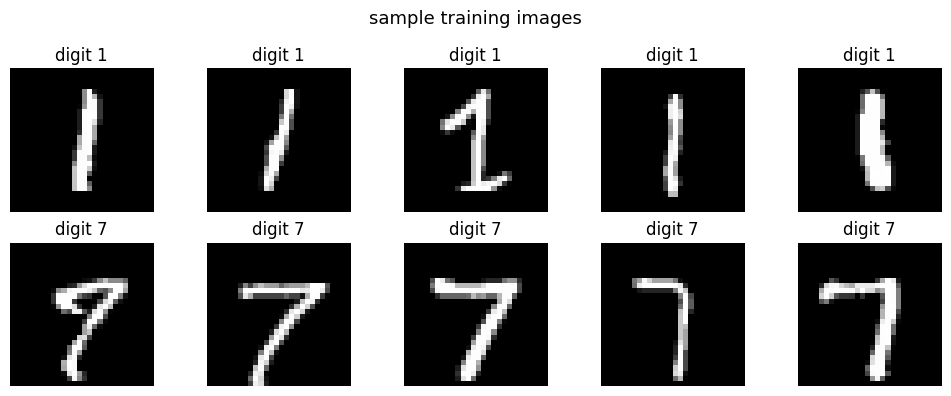

In [5]:
import matplotlib.pyplot as plt

# create a 2 x 5 grid with image ratio as 10 : 4
fig, axes = plt.subplots(2, 5, figsize = (10, 4))

for i, digit in enumerate([1, 7]):
    # find the first 5 indices of the current digit in iteration
    idxs = np.where(y_train == digit)[0][ : 5]
    for j, idx in enumerate(idxs):
        axes[i, j].imshow(X_train[idx], cmap="gray")
        axes[i, j].axis("off")
        axes[i, j].set_title(f"digit {digit}")

plt.suptitle("sample training images", fontsize = 13)
plt.tight_layout()
plt.show()

here, we visualize the five images of each of the two digits that we are going to classify. the style of the digits seem to vary quite a bit

### Data Pre-Processing

we have flatten the array so that linear or non-linear classifiers can use them right 


In [6]:
# flatenning the images from 28x28 to 784
X_train_flat = X_train.reshape(100, -1)
X_test_flat = X_test.reshape(1000, -1)

# normalizing the pixel values / features
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat  / 255.0

print("X_train_flat shape : ", X_train_flat.shape)
print("X_test_flat shape : ", X_test_flat.shape)
print("Pixel range : min = ", X_train_flat.min(), "| max = ", X_train_flat.max())

X_train_flat shape :  (100, 784)
X_test_flat shape :  (1000, 784)
Pixel range : min =  0.0 | max =  1.0


we normalize our data by dividing it by 255 (highest pixel value).

## Building a Classification System

### Model Choice

we choose logistic regression as our first classification model

In [7]:
from sklearn.linear_model import LogisticRegression

# creating a logistic regression model and fitting it
lr = LogisticRegression(random_state = 42)
lr.fit(X_train_flat, y_train)

# displaying accuracy
print("model trained successfully!")
print("training accuracy : ", lr.score(X_train_flat, y_train))

model trained successfully!
training accuracy :  1.0


an accuracy of 1 might mean that the model correctly classified all labels correctly. might indicate overfitting

### Evaluation Metrics

as mentioned earlier, because of the skewed nature of our dataset, we should use metrics like precision, recall and f1 score to gauge our model's performance

In [8]:
from sklearn.metrics import classification_report

# using the logistic regresion model to predict against test set
y_pred_lr = lr.predict(X_test_flat)

print("test accuracy : ", lr.score(X_test_flat, y_test))
print("\nclassification report : ")
print(classification_report(y_test, y_pred_lr, target_names=["digit 1", "digit 7"]))

test accuracy :  0.943

classification report : 
              precision    recall  f1-score   support

     digit 1       0.64      1.00      0.78       100
     digit 7       1.00      0.94      0.97       900

    accuracy                           0.94      1000
   macro avg       0.82      0.97      0.87      1000
weighted avg       0.96      0.94      0.95      1000



classification report gives us a neat table of our our required evaluation metrics

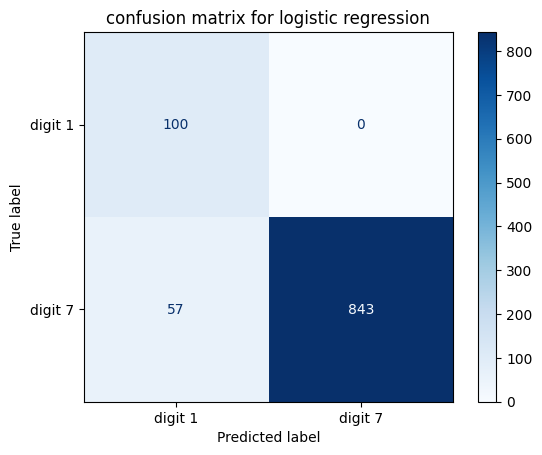

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=["digit 1", "digit 7"])
disp.plot(cmap = "Blues")
plt.title("confusion matrix for logistic regression")
plt.show()

for easily understanding the classification report and it's outputs, we can use a confusion matrix

## Comparison of Two Classifiers and Hyperparameter Tuning

### Hyperparameter Variation

we will vary hyperparameter values across a decent range and determine the appropriate choice using k-fold cross validation

#### Logistic Regression

for logistic regression, we will vary C, the regularization parameter. it controls how strictly the model fits the training data

- small C (e.g. 0.001) -> strong regularisation. model is kept simple = might underfit
- large C (e.g. 100) -> weak regularisation. model fits training data closely = might overfit

the initial accuracy of our model was 1 (100%) with the default value of 1. let's see if we get something different

In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np

# values of C to try
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

# store mean f1 scores for each C
mean_f1_scores = []

# run C values through for loop for cross validation
for C in C_values:
    lr = LogisticRegression(C = C, random_state = 42, max_iter = 1000)
    scores = cross_val_score(lr, X_train_flat, y_train, 
                             cv = 5, scoring = "f1_macro")
    mean_f1_scores.append(scores.mean())
    print(f" C = {C : .3f} | mean f1 : {scores.mean() : .4f} | std : {scores.std() : .4f}")

 C =  0.001 | mean f1 :  0.9599 | std :  0.0374
 C =  0.010 | mean f1 :  0.9799 | std :  0.0246
 C =  0.100 | mean f1 :  0.9900 | std :  0.0201
 C =  1.000 | mean f1 :  0.9900 | std :  0.0201
 C =  10.000 | mean f1 :  0.9900 | std :  0.0201
 C =  100.000 | mean f1 :  0.9900 | std :  0.0201


after a 1000 iterations each loop for different C values, we get the following results

- C = 0.001 : f1 of 0.9599, std of 0.0374 = lower performance and more unstable
- C = 0.01 : f1 jumps to 0.9799, std drops to 0.0246 = big improvement
- C = 0.1 and above : f1 falls flat to 0.9900, std stabalizes at 0.0201

let's try to visualize f1 scores with scaling values of C

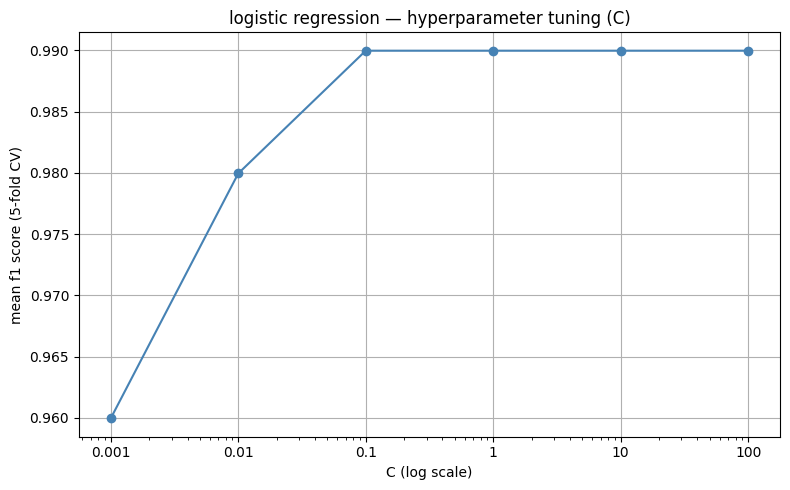

In [11]:
plt.figure(figsize = (8, 5))
plt.plot(C_values, mean_f1_scores, marker = "o", color = "steelblue")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("mean f1 score (5-fold CV)")
plt.title("logistic regression — hyperparameter tuning (C)")
plt.xticks(C_values, labels=[str(c) for c in C_values])
plt.grid(True)
plt.tight_layout()
plt.show()

we use the **xscale("log")** because the C parameters are very small and close to each other (0.001, 0.01, 0.1, 1) compare to the others (1, 10, 100). xscale scales / spaces things equally

we can clearly see the steep improvement and stabalization i mentioned earlier. there is no major improvement after C = 0.1. so we shall go ahead with that it.

In [12]:
best_lr = LogisticRegression(C = 0.1, random_state = 42, max_iter = 1000)
best_lr.fit(X_train_flat, y_train)

print("Best Logistic Regression trained with C = 0.1")
print("Training accuracy:", best_lr.score(X_train_flat, y_train))

Best Logistic Regression trained with C = 0.1
Training accuracy: 1.0


the accuracy doesn't change. this can be because : 

- the data is mostly linearly seperable
- we only have a 100 samples to train from 

when we tested this model with the untouched test data before, the results were pretty good. so our LR model most definitely isn't overfitting the training data. 

the true performance test will be measured when we test both models together

#### Kernel SVM (RBF)

logistic regression can only draw a linear decision boundary between two classes. but if the data isn't linearly seperable, the performance may not be so good.

that is where kernel SVM comes in. we can use a wide variety of kernels to map our non-linear data in higher dimensions. for this assignment, i have chosen the RBF (radial basis function) kernel, which can map our original space into infinite dimensions.

some 1s and 7s may have similar structures making them harder to distinguish from one another. a non-linear decision boundary may help us capture these subtle differences.

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining the hyperparameter dictionary
param_grid = {
    "C" : [0.1, 1, 10, 100],
    "gamma" : [0.0001, 0.001, 0.01, 0.1]
}

# svm with the RBF kernel
svm = SVC(kernel = "rbf", random_state = 42)
# setting up grid search with 5-fold CV
grid_search = GridSearchCV(svm, param_grid, cv = 5, 
                           scoring = "f1_macro", verbose = 1)
# the verbose attribute will print our progress while grid search runs

grid_search.fit(X_train_flat, y_train)

print("\nbest parameters:", grid_search.best_params_)
print("best mean f1 score:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

best parameters: {'C': 10, 'gamma': 0.001}
best mean f1 score: 1.0


we chose smaller values of gamma because we have a lot of featuers in each samples / image. 784 to be exact.

even if individual pixel differences are small for each term, summing them up across all 784 dimensions will create a large distance. 

$$||x - y||² = (x1 - y1)² + (x2 - y2)² + ... + (x784 - y784)²$$

let's say that each individual difference in the formula above averages to 0.01. summing 784 times makes the sum equal to 7.84.

plugging that value in with a default value of C as 1, we get

$$K(x, y) = exp(-γ × ||x - y||²)$$

$$K(x, y) = exp(-1 × 7.84) = exp(-7.84) ≈ 0.00039$$

that value is very close to zero. what that means is that the model may not detect a relationship between samples at all. and therefore, it can't learn any important patterns.

so it becomes really important to select a value of `gamma` that is very small.

---

we use grid search to try every possible combination of hyperparameters from the `param_grid` dictionary.

we have four `C` values and four `gamma` values, so we have **16 combinations**. and since we are running 5-fold CV, we will have 16 * 5 = 80 runs.

since we use 5-fold CV, we only have 80 samples to train from and 20 samples to validate from. with such a small dataset, it's not too surprising that we get a perfect score. just like with LR, we will have to see how the model performs with the test set.

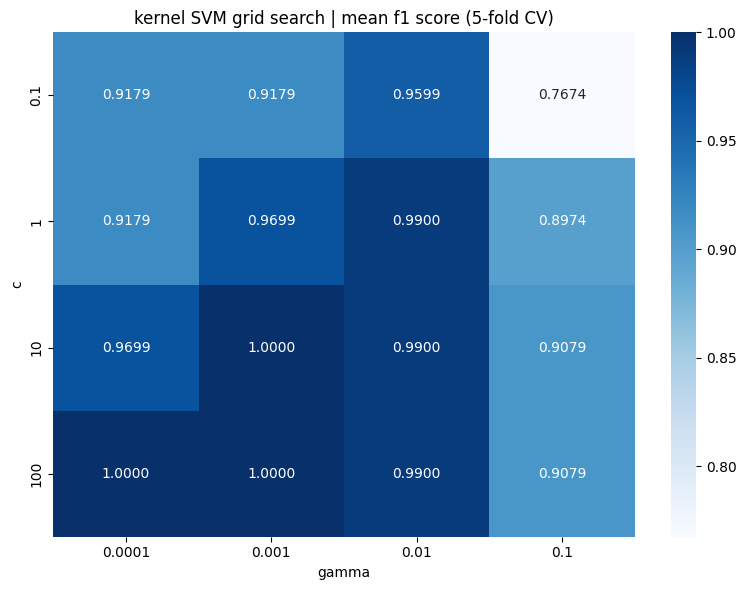

In [16]:
import seaborn as sns

# extract mean test scores and reshape into grid
results = grid_search.cv_results_
scores = results["mean_test_score"].reshape(4, 4)

# plot heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(scores, 
            annot = True, 
            fmt = ".4f",
            xticklabels = [0.0001, 0.001, 0.01, 0.1],
            yticklabels = [0.1, 1, 10, 100],
            cmap = "Blues")

plt.xlabel("gamma")
plt.ylabel("c")
plt.title("kernel SVM grid search | mean f1 score (5-fold CV)")
plt.tight_layout()
plt.show()

we use a heatmap for visualizaiton because mapping 16 combinations with four parameters on just two axes is gonna get messy. a heat map creates a grid, which does a much better job at visualizing our results. color intensity makes things much easier to understand.

some interesting things to note about this heatmap : 

- as `gamma` increases, performance drops, as the model can't learn any meaningful observations.
- as a summary, hyperparameter `C` dictates how many misclassifications are allowed. a higher value of `C` creates a smaller margin, allowing less classifications. and since increasing `C` improves performance, this suggests that the data is fairly linearly seperable, which coincides with our assumption earlier.

---

$C = 10, gamma = 0.001$ is the correct choice. we get the same f1 score as with C = 100, but with a wider margin, which is simpler and generalises better.

In [17]:
# retraining a new SVM model with our best hyperparameters
best_svm = SVC(kernel = "rbf", C = 10, gamma = 0.001, random_state = 42)
best_svm.fit(X_train_flat, y_train)

print("Best Kernel SVM trained with C = 10, gamma = 0.001")
print("Training accuracy:", best_svm.score(X_train_flat, y_train))

Best Kernel SVM trained with C = 10, gamma = 0.001
Training accuracy: 1.0


the training accuracy for non-linear SVM is also 1, which is to be expected.

### Comparing model performance

we shall test the performance of the Logistic Regression and the Kernel SVM (RBF) on the test set. we will use the classification report from earlier to check performance with precision, recall and f1 score.

In [21]:
from sklearn.metrics import classification_report

# logistic regression predictions
y_pred_lr = best_lr.predict(X_test_flat)

# kernel SVM predictions
y_pred_svm = best_svm.predict(X_test_flat)

print("=" * 50)
print("logistic regression")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names = ["digit 1", "digit 7"]))

print("=" * 50)
print("kernel SVM (RBF)")
print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names = ["digit 1", "digit 7"]))

logistic regression
              precision    recall  f1-score   support

     digit 1       0.61      1.00      0.76       100
     digit 7       1.00      0.93      0.96       900

    accuracy                           0.94      1000
   macro avg       0.81      0.97      0.86      1000
weighted avg       0.96      0.94      0.94      1000

kernel SVM (RBF)
              precision    recall  f1-score   support

     digit 1       0.62      1.00      0.76       100
     digit 7       1.00      0.93      0.96       900

    accuracy                           0.94      1000
   macro avg       0.81      0.97      0.86      1000
weighted avg       0.96      0.94      0.94      1000



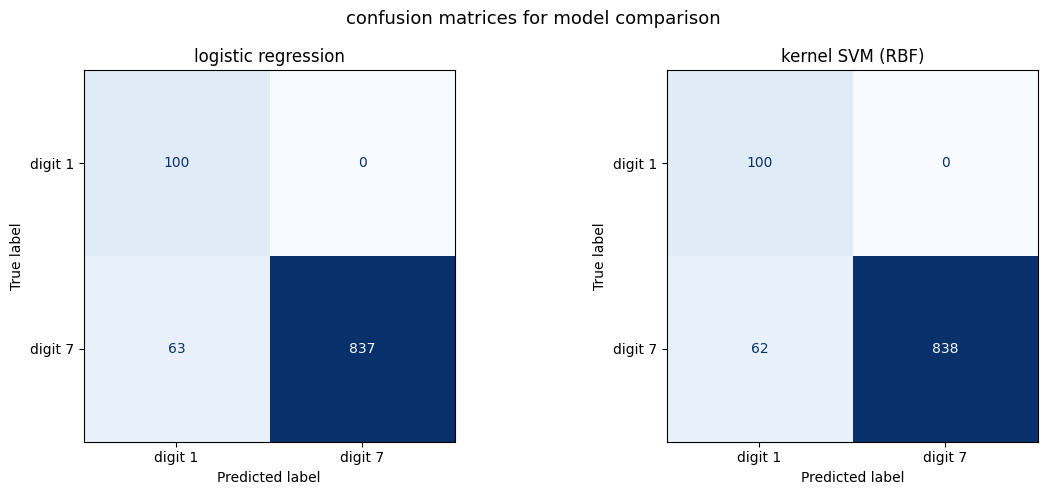

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

for ax, y_pred, title in zip(axes, 
                              [y_pred_lr, y_pred_svm], 
                              ["logistic regression", "kernel SVM (RBF)"]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels = ["digit 1", "digit 7"])
    disp.plot(ax = ax, colorbar = False, cmap = "Blues")
    ax.set_title(title)

plt.suptitle("confusion matrices for model comparison", fontsize = 13)
plt.tight_layout()
plt.show()

a small thing to note. the **performance of our logistic regression got slightly worse after the hyperparameter change**. this is because the hyperparameter tuning was done mainly on the training dataset, which created the performance gap. but thankfully, the performance gap is only minor.

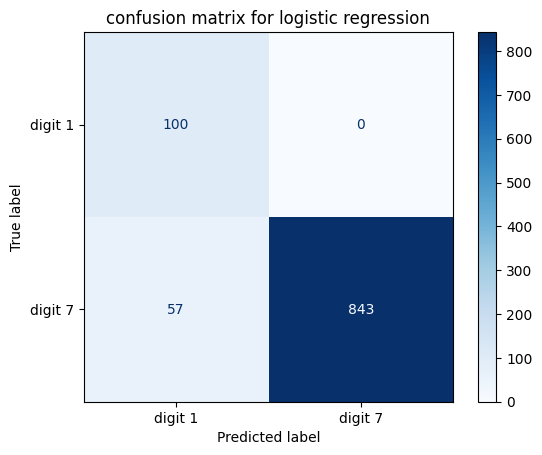

---

despite Kernel SVM (RBF) being more powerful and flexible, both classifiers have identical performance.

the way i interpret this, this test has proven that the **digits 1 and 7 are largely linearly seperable**. combined with the fact that we only have a 100 samples to train with, **we don't have enough complex data for our non-linear model to leverage it's potential**.

## Clustering Analysis of the Test Set

### Clustering the 7s from the test set

In [27]:
# create mask for digit 7 from test set
mask_7 = (y_test == 7)
# use mask to select features of digit 7 samples from test set
X_7 = X_test_flat[mask_7]

print("total test samples : ", len(X_test_flat))
print("digit 7 samples : ", len(X_7))
print("shape : ", X_7.shape)

total test samples :  1000
digit 7 samples :  900
shape :  (900, 784)
